In [6]:
test_dir="/kaggle/input/chest-xray-pneumonia/chest_xray/test/"
train_dir="/kaggle/input/chest-xray-pneumonia/chest_xray/train"
valid_dir="/kaggle/input/chest-xray-pneumonia/chest_xray/val/"


# import library

In [15]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, Dropout,Conv2D, BatchNormalization ,Flatten,GlobalAveragePooling2D,Activation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

In [16]:
img_size = (224, 224)
batch_size = 32

# Augmentation

In [17]:
from tensorflow.keras.applications.densenet import preprocess_input
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,           # Increased
    width_shift_range=0.2,       # Increased
    height_shift_range=0.2,      # Increased
    shear_range=0.15,            # NEW - helps with overfitting
    zoom_range=0.2,              # Increased
    horizontal_flip=True,
    vertical_flip=True,          # NEW - medical images can be flipped vertically
    fill_mode='nearest',
    validation_split=0.15

)


test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Data generation

In [18]:
train_data=train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,  # by default it takes rgb colo image
    batch_size=32,
    color_mode='rgb',
    class_mode='binary',
    subset='training',
    shuffle=True
)
valid_data=train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=32,
    class_mode='binary',
    subset='validation',
 
    shuffle=False
)
test_data=test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=32,
    class_mode='binary',
     shuffle=False

)

Found 4434 images belonging to 2 classes.
Found 782 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


# train model

In [152]:
base_model=DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
# freeze  all layer of resnet base model
for layers in base_model.layers:
    layers.trainable=False

# Custom model creation

In [155]:
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

# Build simpler model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)  # Added L2 regularization
x = Dropout(0.6)(x)  # Increased dropout
x = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(x)   # Smaller layer
x = Dropout(0.5)(x)
output = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)


# compile model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='crossentropy',      # my model is hot encoding formate [1 0 0 0]
    metrics=['accuracy']
)


In [156]:
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_16   │ (None, 230, 230,  │          0 │ input_layer_8[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_1… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_17   │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,177,090 (27.38 MB)

 Trainable params: 139,586 (545.26 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

# Apply call backs

In [163]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,           # Stop if no improvement for 10 epochs
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,            # Reduce learning rate by half
        patience=5,            # Wait 5 epochs before reducing
        min_lr=0.000001        # Minimum learning rate
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max'
    )
]

In [164]:
history = model.fit(
    train_data,
    steps_per_epoch=len(train_data),
    validation_data=valid_data,
    validation_steps=len(valid_data),
    epochs=50,  # Increased epochs
    #class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 100s 656ms/step - accuracy: 0.6691 - loss: 3.4780 - val_accuracy: 0.8031 - val_loss: 2.8393 - learning_rate: 1.0000e-04
Epoch 2/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 89s 640ms/step - accuracy: 0.7648 - loss: 2.6372 - val_accuracy: 0.8529 - val_loss: 2.2951 - learning_rate: 1.0000e-04
Epoch 3/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 90s 642ms/step - accuracy: 0.8067 - loss: 2.1721 - val_accuracy: 0.8939 - val_loss: 1.9107 - learning_rate: 1.0000e-04
Epoch 4/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 87s 623ms/step - accuracy: 0.8408 - loss: 1.8560 - val_accuracy: 0.8939 - val_loss: 1.6614 - learning_rate: 1.0000e-04
Epoch 5/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 87s 627ms/step - accuracy: 0.8669 - loss: 1.6344 - val_accuracy: 0.8875 - val_loss: 1.5048 - learning_rate: 1.0000e-04
Epoch 6/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 88s 632ms/step - accuracy: 0.8762 - loss: 1.4742 - val_accuracy: 0.9079 - val_loss: 1.3533 - learning_rate: 1.0000e-04
Epoch 7/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 88s 6

In [24]:

from tensorflow.keras.models import load_model
model = load_model("/kaggle/input/pnemonia-best-model/keras/default/1/best_model (5).keras")


test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 491ms/step - accuracy: 0.8974 - loss: 0.4102
Test Accuracy: 0.8974359035491943


# Evalution

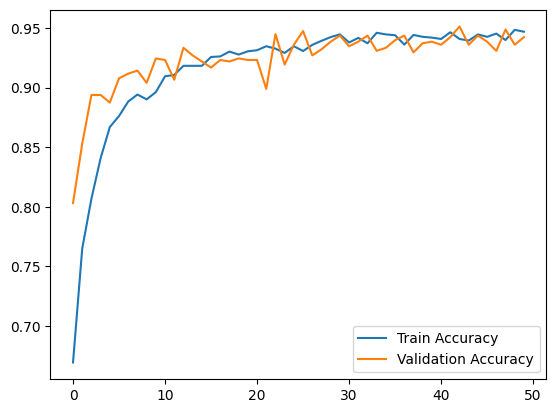

In [168]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

In [25]:

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


# Reset generator (VERY IMPORTANT)
test_data.reset()

# Predict probabilities
y_pred_probs = model.predict(test_data, verbose=1)

# Convert probabilities → class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_data.classes

# Class names
class_names = list(test_data.class_indices.keys())


     

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 607ms/step


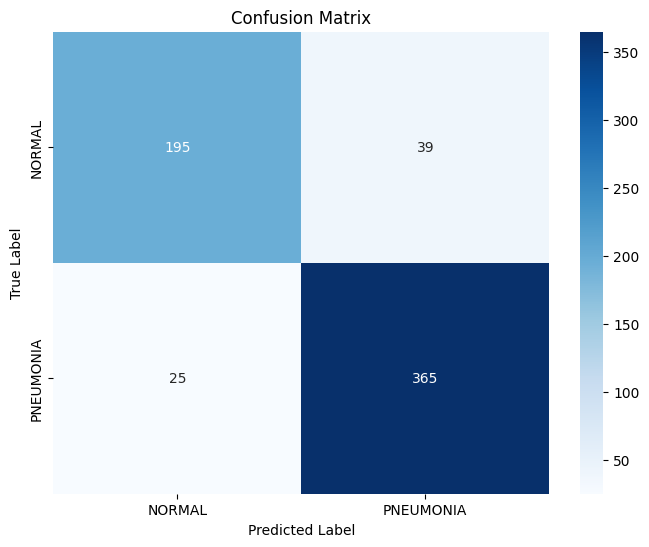

In [27]:

import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


# classification report

In [28]:

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print("Classification Report:\n")
print(report)


Classification Report:

              precision    recall  f1-score   support

      NORMAL       0.89      0.83      0.86       234
   PNEUMONIA       0.90      0.94      0.92       390

    accuracy                           0.90       624
   macro avg       0.89      0.88      0.89       624
weighted avg       0.90      0.90      0.90       624



In [32]:

from sklearn.metrics import confusion_matrix
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Row-wise normalization (per true class)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


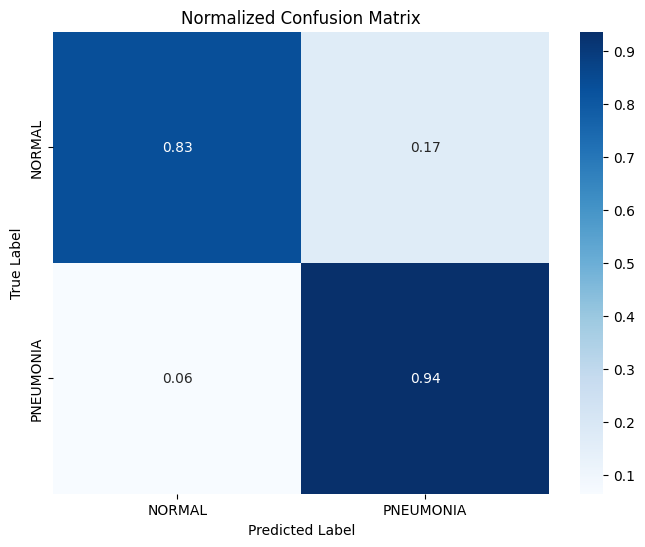

In [33]:
plt.figure(figsize=(8,6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.show()
